# Stock Price Prediction Using Python and ML

## Import required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import yfinance as yf
import joblib

## Download Stock Data

In [2]:
stock = yf.download("AAPL", start="2020-01-01", end="2025-01-01")

[*********************100%***********************]  1 of 1 completed


In [3]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.333870,72.394078,71.091176,71.344047,135480400
2020-01-03,71.630646,72.389265,71.406674,71.563213,146322800
2020-01-06,72.201408,72.239942,70.503546,70.754014,118387200
2020-01-07,71.861855,72.466338,71.642697,72.211056,108872000
2020-01-08,73.017845,73.318885,71.565629,71.565629,132079200


## Check Dataset

In [4]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2020-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1258 non-null   float64
 1   (High, AAPL)    1258 non-null   float64
 2   (Low, AAPL)     1258 non-null   float64
 3   (Open, AAPL)    1258 non-null   float64
 4   (Volume, AAPL)  1258 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 59.0 KB


In [5]:
stock.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1258.000000,1258.000000,1258.000000,1258.000000,1.258000e+03
mean,151.377786,152.899567,149.680872,151.223470,9.057103e+07
std,41.851999,41.992363,41.629303,41.795805,5.324438e+07
min,54.163704,55.160702,51.324800,55.059313,2.323470e+07
25%,126.279102,127.397079,124.278508,125.724400,5.546825e+07
50%,149.968628,151.709750,148.037194,149.788890,7.628335e+07
75%,175.902012,177.452448,174.337234,175.708227,1.077425e+08
max,257.375580,258.448740,255.994420,256.550862,4.265100e+08


In [6]:
stock.isnull().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

## Visualize Price

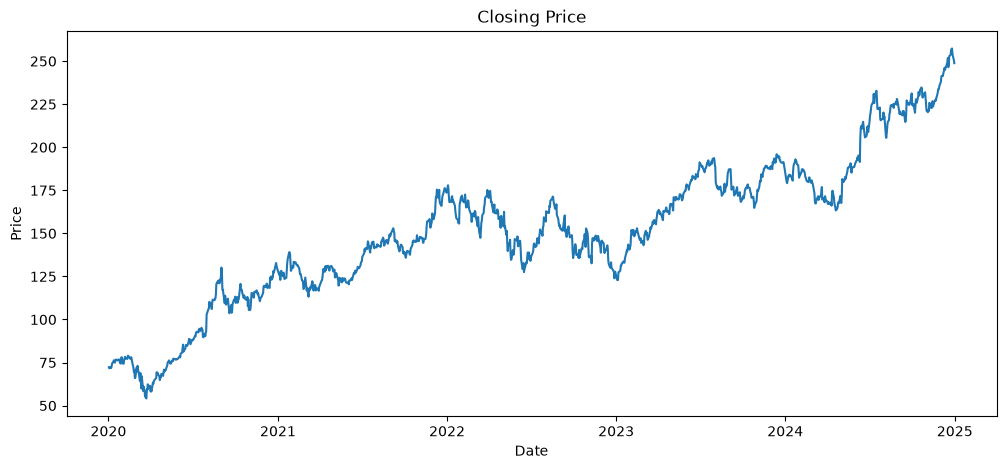

In [4]:
plt.figure(figsize=(12,5))
plt.plot(stock['Close'])
plt.title("Closing Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

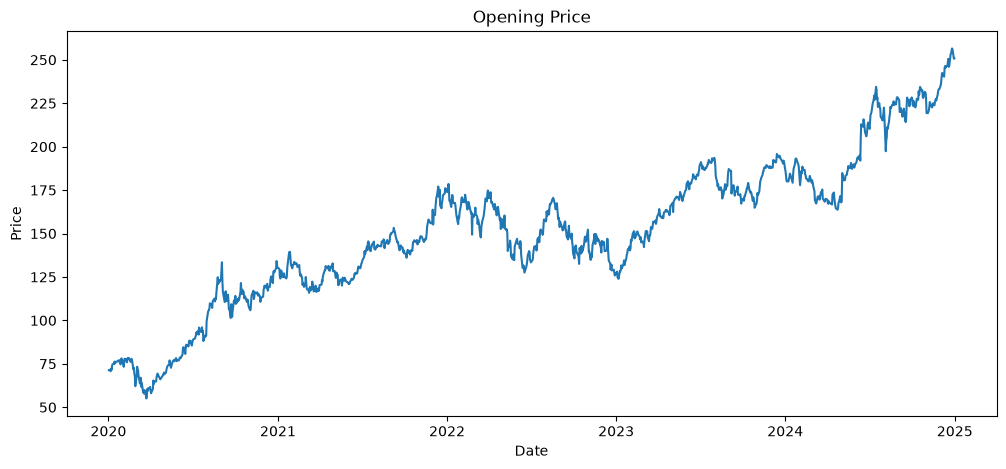

In [5]:
plt.figure(figsize=(12,5))
plt.plot(stock['Open'])
plt.title("Opening Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

## Create Features

In [6]:
# Create a column for tomorrow's closing price
stock['Target'] = stock['Close'].shift(-1)

In [7]:
stock.dropna(inplace=True)

## Select Features

In [8]:
x = stock[['Open', 'High', 'Low', 'Close', 'Volume']]
y = stock['Target']

In [17]:
x

Price,Open,High,Low,Close,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,


In [18]:
y

Series([], Name: Target, dtype: float64)

## Split DataSet

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

## Create ML Model

In [10]:
model = LinearRegression()

## Train the Model

In [11]:
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# Predict Closing price

In [14]:
prediction = model.predict(x_test)

## Evaluate Model

In [15]:
mae = mean_absolute_error(y_test, prediction)

mse = mean_squared_error(y_test, prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, prediction)



In [16]:
mae

2.002700393851965

In [17]:
rmse

np.float64(2.7504200142766932)

In [18]:
r2

0.9956803322603458

## Compare Actual vs Predicted

In [19]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": prediction
})

result

,Actual,Predicted
Date,,
2021-09-23,143.425079,143.473185
2020-05-28,76.959579,77.696373
2020-03-17,59.547005,61.361238
2020-04-02,58.277222,59.359624
2024-04-08,167.985016,167.119160
...,...,...
2020-08-14,111.166245,111.540969
2021-12-06,167.351883,162.582090
2021-08-02,143.639435,142.216901


## Plot prediction

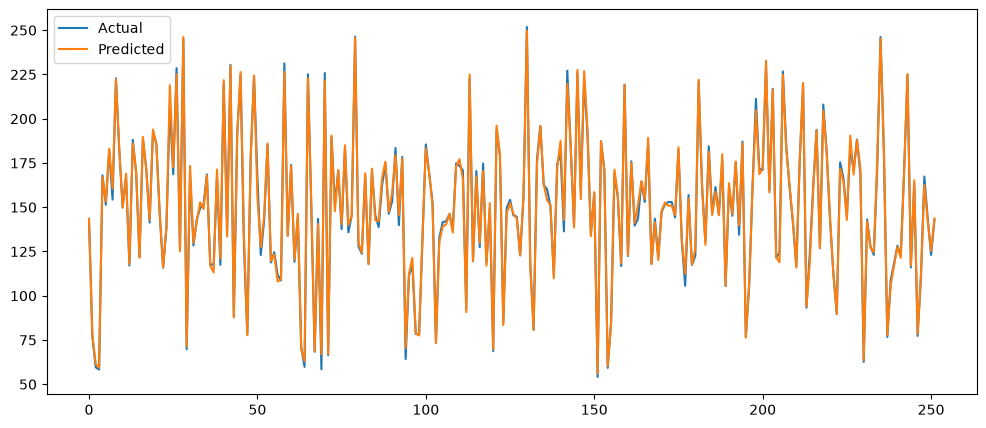

In [22]:
plt.figure(figsize=(12,5))

plt.plot(result['Actual'].values, label="Actual")

plt.plot(result['Predicted'].values, label="Predicted")

plt.legend()

## Save the model

In [24]:
joblib.dump(model, "stock_prediction_model.pkl")

['stock_prediction_model.pkl']

# Load saved model

In [25]:
saved_model = joblib.load("stock_prediction_model.pkl")


In [26]:
sample = [[180, 182, 176, 191, 70000]]

prediction = saved_model.predict(sample)

prediction

array([187.06088985])